In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/IMDB Dataset.csv')

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 50000
Number of columns: 2


In [8]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
review       0
sentiment    0
dtype: int64


In [9]:
print(df["sentiment"].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

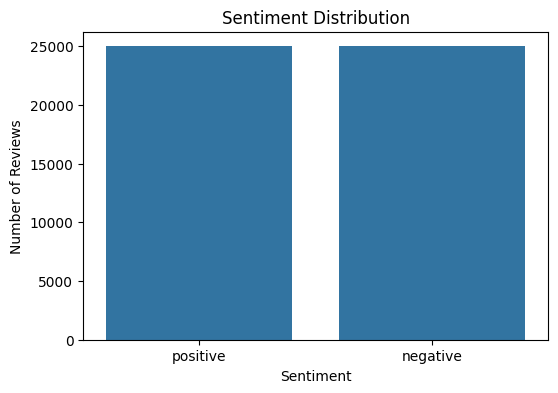

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="sentiment")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [12]:
print("Number of unique sentiment classes:", df["sentiment"].nunique())

Number of unique sentiment classes: 2


In [13]:
print("Sentiment classes:", df["sentiment"].unique())

Sentiment classes: ['positive' 'negative']


### Task 1 Conclusion

The dataset contains 50,000 movie reviews with two columns: `review` and `sentiment`. There are no missing values in the dataset. The sentiment column contains two classes: Positive and Negative. The dataset is approximately balanced, with 25,000 positive and 25,000 negative reviews. Since the dataset contains 50,000 reviews, it satisfies the requirement of having at least 2,000 reviews for the sentiment analysis project.

In [14]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [15]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [16]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [17]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    # Join tokens back into text
    return ' '.join(tokens)

In [18]:
print("Original Review:")
print(df["review"].iloc[0])

print("\nCleaned Review:")
print(preprocess_text(df["review"].iloc[0]))

Original Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [19]:
df["cleaned_review"] = df["review"].apply(preprocess_text)

In [20]:
df[["review", "cleaned_review"]].head(5)

,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


In [21]:
empty_reviews = (df["cleaned_review"].str.strip() == "").sum()

print("Number of empty cleaned reviews:", empty_reviews)

Number of empty cleaned reviews: 0


In [22]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (50000, 3)

Columns:
['review', 'sentiment', 'cleaned_review']


In [23]:
from collections import Counter

all_words = " ".join(df["cleaned_review"]).split()

word_counts = Counter(all_words)

print("Total number of words:", len(all_words))
print("Unique words:", len(word_counts))

Total number of words: 5906540
Unique words: 89812


In [24]:
top_20_words = word_counts.most_common(20)

print("Top 20 Most Frequent Words:\n")

for word, count in top_20_words:
    print(f"{word}: {count}")

Top 20 Most Frequent Words:

movie: 103281
film: 93463
one: 55450
like: 41132
time: 31470
good: 29868
character: 28361
story: 25276
even: 24873
get: 24658
would: 24602
make: 24210
see: 24072
really: 23095
scene: 21450
well: 21445
much: 19320
bad: 18474
people: 18368
great: 18226


In [25]:
positive_words = " ".join(
    df[df["sentiment"] == "positive"]["cleaned_review"]
).split()

positive_word_counts = Counter(positive_words)

print("Top 20 words in Positive reviews:\n")

for word, count in positive_word_counts.most_common(20):
    print(f"{word}: {count}")

Top 20 words in Positive reviews:

film: 49712
movie: 44850
one: 28288
like: 18198
time: 16318
good: 15094
story: 14185
character: 14028
great: 13012
see: 12931
well: 12832
make: 11244
get: 11194
also: 10793
really: 10740
would: 10595
scene: 10058
life: 9902
show: 9664
even: 9618


In [26]:
negative_words = " ".join(
    df[df["sentiment"] == "negative"]["cleaned_review"]
).split()

negative_word_counts = Counter(negative_words)

print("Top 20 words in Negative reviews:\n")

for word, count in negative_word_counts.most_common(20):
    print(f"{word}: {count}")

Top 20 words in Negative reviews:

movie: 58431
film: 43751
one: 27162
like: 22934
even: 15255
time: 15152
good: 14774
bad: 14726
character: 14333
would: 14007
get: 13464
make: 12966
really: 12355
scene: 11392
see: 11141
story: 11091
much: 10118
people: 9540
thing: 9474
could: 9300


In [27]:
from wordcloud import WordCloud

In [28]:
!pip install wordcloud

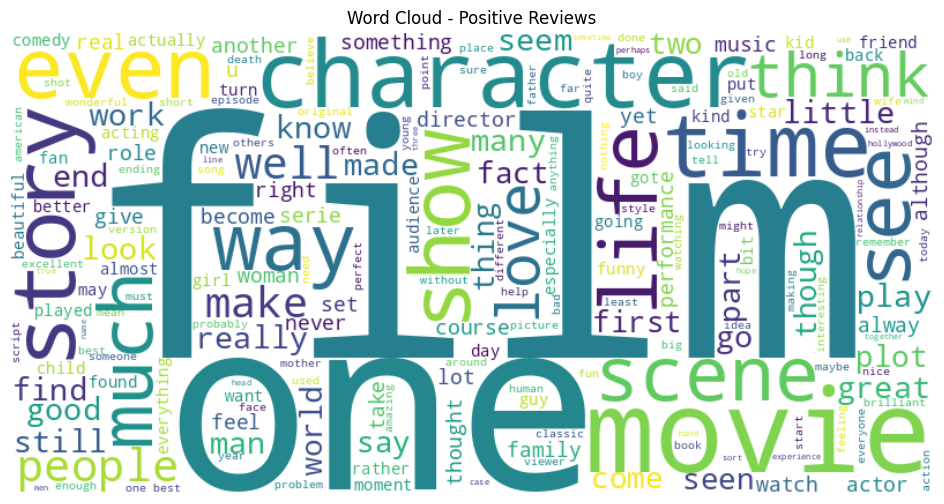

In [29]:
positive_text = " ".join(df[df["sentiment"] == "positive"]["cleaned_review"])

positive_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Positive Reviews")
plt.show()

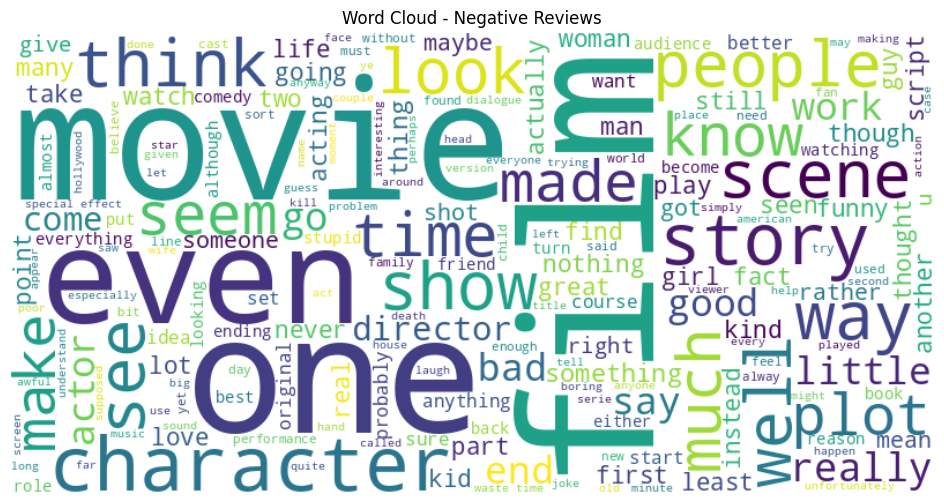

In [30]:
negative_text = " ".join(df[df["sentiment"] == "negative"]["cleaned_review"])

negative_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Negative Reviews")
plt.show()

In [31]:
from sklearn.model_selection import train_test_split

X = df["cleaned_review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 40000
Testing samples: 10000


In [32]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

In [33]:
X_train_bow = vectorizer.fit_transform(X_train)

print("X_train shape:", X_train_bow.shape)

X_train shape: (40000, 81485)


In [34]:
X_test_bow = vectorizer.transform(X_test)

print("X_test shape:", X_test_bow.shape)

X_test shape: (10000, 81485)


In [35]:
vocabulary = vectorizer.get_feature_names_out()

print("Vocabulary size:", len(vocabulary))
print("\nFirst 50 vocabulary words:")
print(vocabulary[:50])

Vocabulary size: 81485

First 50 vocabulary words:
['aa' 'aaa' 'aaaaaaaargh' 'aaaaaaahhhhhhggg' 'aaaaagh' 'aaaaah'
 'aaaaahhhh' 'aaaaargh' 'aaaaarrrrrrgggggghhhhhh' 'aaaahhhhhh'
 'aaaahhhhhhh' 'aaaand' 'aaaarrgh' 'aaaggghhhhhhh' 'aaagh' 'aaah'
 'aaahhhhhhh' 'aaall' 'aaam' 'aaand' 'aaargh' 'aaarrrgh' 'aaawwwwnnn'
 'aab' 'aachen' 'aada' 'aag' 'aage' 'aagh' 'aaghh' 'aah' 'aahe' 'aahed'
 'aahhh' 'aahhhh' 'aahing' 'aaila' 'aailiyah' 'aaip' 'aaja' 'aajala' 'aak'
 'aakash' 'aake' 'aaker' 'aalcc' 'aaliyah' 'aalox' 'aames' 'aamir']


In [36]:
print("First review:")
print(X_train.iloc[0])

print("\nBag of Words vector:")
print(X_train_bow[0].toarray())

First review:
caught little gem totally accident back revival theatre see two old silly sci fi movie theatre packed full warning showed bunch sci fi short spoof get u mood somewhat amusing came within second audience hysteric biggest laugh came showed princess laia huge cinnamon bun instead hair head look camera give grim smile nod made even funnier got ta see chewabacca played look like muppet extremely silly stupid stop laughing dialogue drowned laughter also know star war pretty well even funnier deliberately poke fun dialogue really work audience definite

Bag of Words vector:
[[0 0 0 ... 0 0 0]]


In [37]:
# Convert only the first 3 reviews to dense arrays
X_train_sample = X_train_bow[:3].toarray()

print("Sample BoW matrix shape:", X_train_sample.shape)

Sample BoW matrix shape: (3, 81485)


In [38]:
# Convert only the first 3 reviews to dense arrays
X_train_sample = X_train_bow[:3].toarray()

print("Sample BoW matrix shape:", X_train_sample.shape)

Sample BoW matrix shape: (3, 81485)


In [39]:
non_zero_indices = np.where(X_train_sample[0] != 0)[0]

print("Non-zero feature positions:")
print(non_zero_indices)

Non-zero feature positions:
[  389  1918  2303  4277  4822  6894  9545  9547 10187 10194 11114 12050
 12680 17608 17779 18753 20848 23674 24370 25479 27531 27566 27620 28410
 28661 29047 29735 30237 31055 31911 33821 34210 35877 39411 40186 40653
 40659 40664 41562 41879 42230 43142 47220 47667 48021 49636 50765 52064
 54602 54905 55967 56061 58310 60096 63016 63435 63505 64824 64894 65290
 66209 66815 67615 68089 68663 69136 70625 71916 73174 74530 78376 78434
 78848 79777 80060]


In [40]:
for index in non_zero_indices:
    print(f"Position {index}: {vocabulary[index]} = {X_train_sample[0][index]}")

Position 389: accident = 1
Position 1918: also = 1
Position 2303: amusing = 1
Position 4277: audience = 2
Position 4822: back = 1
Position 6894: biggest = 1
Position 9545: bun = 1
Position 9547: bunch = 1
Position 10187: came = 2
Position 10194: camera = 1
Position 11114: caught = 1
Position 12050: chewabacca = 1
Position 12680: cinnamon = 1
Position 17608: definite = 1
Position 17779: deliberately = 1
Position 18753: dialogue = 2
Position 20848: drowned = 1
Position 23674: even = 2
Position 24370: extremely = 1
Position 25479: fi = 2
Position 27531: full = 1
Position 27566: fun = 1
Position 27620: funnier = 2
Position 28410: gem = 1
Position 28661: get = 1
Position 29047: give = 1
Position 29735: got = 1
Position 30237: grim = 1
Position 31055: hair = 1
Position 31911: head = 1
Position 33821: huge = 1
Position 34210: hysteric = 1
Position 35877: instead = 1
Position 39411: know = 1
Position 40186: laia = 1
Position 40653: laugh = 1
Position 40659: laughing = 1
Position 40664: laughte

In [41]:
for i in range(3):
    print(f"\nReview {i + 1}:")
    print(X_train.iloc[i])

    non_zero = np.where(X_train_sample[i] != 0)[0]

    print("\nWords and their counts:")
    for index in non_zero:
        print(f"{vocabulary[index]}: {X_train_sample[i][index]}")


Review 1:
caught little gem totally accident back revival theatre see two old silly sci fi movie theatre packed full warning showed bunch sci fi short spoof get u mood somewhat amusing came within second audience hysteric biggest laugh came showed princess laia huge cinnamon bun instead hair head look camera give grim smile nod made even funnier got ta see chewabacca played look like muppet extremely silly stupid stop laughing dialogue drowned laughter also know star war pretty well even funnier deliberately poke fun dialogue really work audience definite

Words and their counts:
accident: 1
also: 1
amusing: 1
audience: 2
back: 1
biggest: 1
bun: 1
bunch: 1
came: 2
camera: 1
caught: 1
chewabacca: 1
cinnamon: 1
definite: 1
deliberately: 1
dialogue: 2
drowned: 1
even: 2
extremely: 1
fi: 2
full: 1
fun: 1
funnier: 2
gem: 1
get: 1
give: 1
got: 1
grim: 1
hair: 1
head: 1
huge: 1
hysteric: 1
instead: 1
know: 1
laia: 1
laugh: 1
laughing: 1
laughter: 1
like: 1
little: 1
look: 2
made: 1
mood: 1
m

In [42]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

print("Multinomial Naive Bayes model created successfully.")

Multinomial Naive Bayes model created successfully.


In [43]:
nb_model.fit(X_train_bow, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [44]:
y_pred = nb_model.predict(X_test_bow)

print("Prediction completed.")
print("First 10 predictions:")
print(y_pred[:10])

Prediction completed.
First 10 predictions:
['negative' 'positive' 'positive' 'negative' 'negative' 'negative'
 'negative' 'negative' 'negative' 'negative']


In [46]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8597
Accuracy (%): 85.97


In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, pos_label="positive")
recall = recall_score(y_test, y_pred, pos_label="positive")
f1 = f1_score(y_test, y_pred, pos_label="positive")

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.8758620689655172
Recall: 0.8382
F1-score: 0.856617271333674


In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.84      0.88      0.86      5000
    positive       0.88      0.84      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4406  594]
 [ 809 4191]]


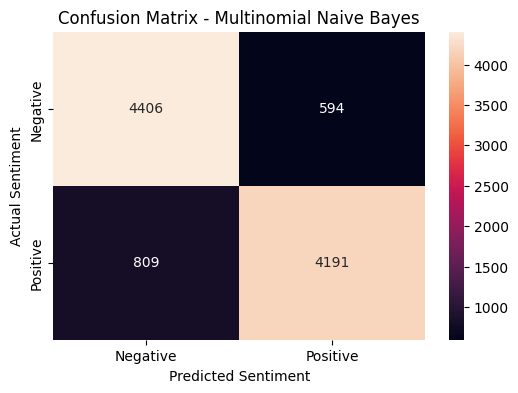

In [50]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.show()

In [51]:
tn, fp, fn, tp = cm.ravel()

print("True Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive (TP):", tp)

True Negative (TN): 4406
False Positive (FP): 594
False Negative (FN): 809
True Positive (TP): 4191


In [52]:
new_reviews = [
    "This movie was absolutely fantastic and I loved every scene.",
    "The acting was brilliant and the story was very engaging.",
    "I really enjoyed this wonderful movie from beginning to end.",
    "The film was entertaining, emotional, and beautifully directed.",
    "Amazing performances and an excellent storyline made this movie unforgettable.",
    "The movie was extremely boring and disappointing.",
    "The acting was terrible and the story was weak.",
    "I hated this movie because it was slow and completely uninteresting.",
    "This was a horrible film with poor acting and a predictable story.",
    "The movie was a complete waste of time and very disappointing."
]

print("Number of new reviews:", len(new_reviews))

Number of new reviews: 10


In [53]:
cleaned_new_reviews = [
    preprocess_text(review)
    for review in new_reviews
]

for i, review in enumerate(cleaned_new_reviews, 1):
    print(f"{i}. {review}")

1. movie absolutely fantastic loved every scene
2. acting brilliant story engaging
3. really enjoyed wonderful movie beginning end
4. film entertaining emotional beautifully directed
5. amazing performance excellent storyline made movie unforgettable
6. movie extremely boring disappointing
7. acting terrible story weak
8. hated movie slow completely uninteresting
9. horrible film poor acting predictable story
10. movie complete waste time disappointing


In [54]:
new_reviews_bow = vectorizer.transform(cleaned_new_reviews)

print("New reviews BoW shape:", new_reviews_bow.shape)

New reviews BoW shape: (10, 81485)


In [55]:
new_predictions = nb_model.predict(new_reviews_bow)

for i, prediction in enumerate(new_predictions, 1):
    print(f"Review {i}: {prediction}")

Review 1: positive
Review 2: positive
Review 3: positive
Review 4: positive
Review 5: positive
Review 6: negative
Review 7: negative
Review 8: negative
Review 9: negative
Review 10: negative


In [56]:
results = pd.DataFrame({
    "Review": new_reviews,
    "Predicted Sentiment": new_predictions
})

results

,Review,Predicted Sentiment
0,This movie was absolutely fantastic and I love...,positive
1,The acting was brilliant and the story was ver...,positive
2,I really enjoyed this wonderful movie from beg...,positive
3,"The film was entertaining, emotional, and beau...",positive
4,Amazing performances and an excellent storylin...,positive
5,The movie was extremely boring and disappointing.,negative
6,The acting was terrible and the story was weak.,negative
7,I hated this movie because it was slow and com...,negative
8,This was a horrible film with poor acting and ...,negative
9,The movie was a complete waste of time and ver...,negative


In [57]:
vectorizer_default = CountVectorizer()

X_train_default = vectorizer_default.fit_transform(X_train)
X_test_default = vectorizer_default.transform(X_test)

model_default = MultinomialNB()
model_default.fit(X_train_default, y_train)

y_pred_default = model_default.predict(X_test_default)

accuracy_default = accuracy_score(y_test, y_pred_default)

print("Default BoW")
print("Vocabulary Size:", len(vectorizer_default.get_feature_names_out()))
print("Accuracy:", accuracy_default)
print("Accuracy (%):", accuracy_default * 100)

Default BoW
Vocabulary Size: 81485
Accuracy: 0.8597
Accuracy (%): 85.97


In [58]:
vectorizer_max = CountVectorizer(max_features=5000)

X_train_max = vectorizer_max.fit_transform(X_train)
X_test_max = vectorizer_max.transform(X_test)

model_max = MultinomialNB()
model_max.fit(X_train_max, y_train)

y_pred_max = model_max.predict(X_test_max)

accuracy_max = accuracy_score(y_test, y_pred_max)

print("BoW with max_features=5000")
print("Vocabulary Size:", len(vectorizer_max.get_feature_names_out()))
print("Accuracy:", accuracy_max)
print("Accuracy (%):", accuracy_max * 100)

BoW with max_features=5000
Vocabulary Size: 5000
Accuracy: 0.8495
Accuracy (%): 84.95


In [59]:
vectorizer_min = CountVectorizer(min_df=5)

X_train_min = vectorizer_min.fit_transform(X_train)
X_test_min = vectorizer_min.transform(X_test)

model_min = MultinomialNB()
model_min.fit(X_train_min, y_train)

y_pred_min = model_min.predict(X_test_min)

accuracy_min = accuracy_score(y_test, y_pred_min)

print("BoW with min_df=5")
print("Vocabulary Size:", len(vectorizer_min.get_feature_names_out()))
print("Accuracy:", accuracy_min)
print("Accuracy (%):", accuracy_min * 100)

BoW with min_df=5
Vocabulary Size: 29365
Accuracy: 0.8578
Accuracy (%): 85.78


In [60]:
comparison = pd.DataFrame({
    "BoW Configuration": [
        "Default BoW",
        "max_features=5000",
        "min_df=5"
    ],
    "Vocabulary Size": [
        len(vectorizer_default.get_feature_names_out()),
        len(vectorizer_max.get_feature_names_out()),
        len(vectorizer_min.get_feature_names_out())
    ],
    "Accuracy": [
        accuracy_default,
        accuracy_max,
        accuracy_min
    ]
})

comparison["Accuracy (%)"] = comparison["Accuracy"] * 100

comparison

,BoW Configuration,Vocabulary Size,Accuracy,Accuracy (%)
0,Default BoW,81485,0.8597,85.97
1,max_features=5000,5000,0.8495,84.95
2,min_df=5,29365,0.8578,85.78


In [61]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("Best BoW Configuration:", best_model["BoW Configuration"])
print("Vocabulary Size:", best_model["Vocabulary Size"])
print("Accuracy:", best_model["Accuracy (%)"], "%")

Best BoW Configuration: Default BoW
Vocabulary Size: 81485
Accuracy: 85.97 %


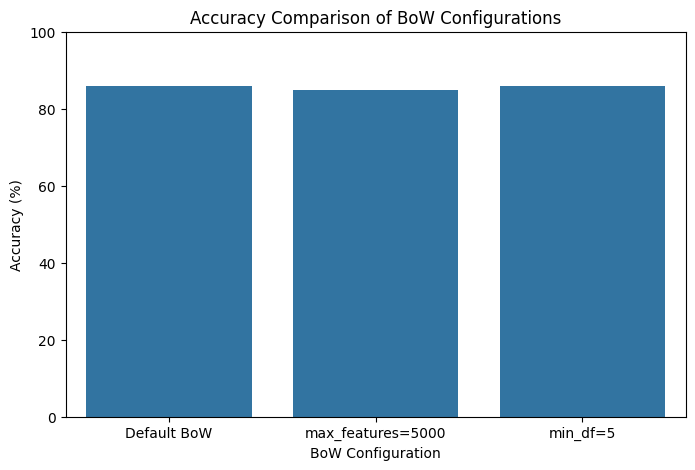

In [62]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="BoW Configuration",
    y="Accuracy (%)"
)

plt.title("Accuracy Comparison of BoW Configurations")
plt.xlabel("BoW Configuration")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.show()

In [63]:
print("========== PROJECT RESULTS ==========")

print("\nDataset:")
print("Total Reviews:", len(df))
print("Training Reviews:", len(X_train))
print("Testing Reviews:", len(X_test))

print("\nNaive Bayes Performance:")
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

print("\nBoW Configuration Comparison:")
print(comparison.to_string(index=False))

print("\nBest Configuration:")
print(best_model["BoW Configuration"])

========== PROJECT RESULTS ==========

Dataset:
Total Reviews: 50000
Training Reviews: 40000
Testing Reviews: 10000

Naive Bayes Performance:
Accuracy: 85.97 %
Precision: 0.8759
Recall: 0.8382
F1-score: 0.8566

BoW Configuration Comparison:
BoW Configuration  Vocabulary Size  Accuracy  Accuracy (%)
      Default BoW            81485    0.8597         85.97
max_features=5000             5000    0.8495         84.95
         min_df=5            29365    0.8578         85.78

Best Configuration:
Default BoW
